# SINDy on the Lorenz System

This notebook applies the from-scratch SINDy implementation to the Lorenz system.

The Lorenz system is a classic nonlinear dynamical system:

x_dot = sigma * (y - x)

y_dot = x * (rho - z) - y

z_dot = x * y - beta * z

The goal is to show that SINDy can recover sparse nonlinear governing equations from a larger polynomial candidate library.

This provides a clean contrast to the real financial data experiments:

- In the Lorenz system, the true governing equations are sparse and stable.
- In real daily financial data, the underlying dynamics are noisy, regime-dependent, and not well described by a simple autonomous equation.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from src.library import build_polynomial_library
from src.stlsq import stlsq

## Lorenz system

The true system is:

x_dot = sigma * (y - x)

y_dot = rho * x - y - x * z

z_dot = x * y - beta * z

We use the classical parameter values:

sigma = 10

rho = 28

beta = 8/3

The important point for SINDy is that the right-hand side is sparse in a degree-2 polynomial library.

The candidate library will include:

[1, x, y, z, x^2, xy, xz, y^2, yz, z^2]

Only a few of these terms are actually needed.

In [3]:
def lorenz_rhs(t, state, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    x, y, z = state

    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    return [dxdt, dydt, dzdt]

## Simulate Lorenz data

We simulate one trajectory and collect the state matrix:

X = [x, y, z]

with shape:

n_samples x 3

We also evaluate the true derivatives from the known Lorenz equation. This avoids numerical derivative noise and gives a clean recovery experiment.

In [5]:
dt = 0.01
t_start = 0.0
t_end = 30.0

t_eval = np.arange(t_start, t_end, dt)

initial_state = [1.0, 1.0, 1.0]

solution = solve_ivp(
    fun=lorenz_rhs,
    t_span=(t_start, t_end),
    y0=initial_state,
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-10,
)

X = solution.y.T

dXdt = np.array([
    lorenz_rhs(t, state)
    for t, state in zip(t_eval, X)
])

print("X shape:", X.shape)
print("dXdt shape:", dXdt.shape)
print("First 5 states:")
print(X[:5])
print("First 5 derivatives:")
print(dXdt[:5])

X shape: (3000, 3)
dXdt shape: (3000, 3)
First 5 states:
[[1.         1.         1.        ]
 [1.01256573 1.25992003 0.98489104]
 [1.04882146 1.52400085 0.97311434]
 [1.10720628 1.79831461 0.96515909]
 [1.18686546 2.08854557 0.96173737]]
First 5 derivatives:
[[ 0.         26.         -1.66666667]
 [ 2.47354293 26.09465357 -1.35062427]
 [ 4.75179393 26.82237672 -0.99656678]
 [ 6.91108332 28.13483103 -0.58265235]
 [ 9.01680109 30.00223454 -0.08581036]]


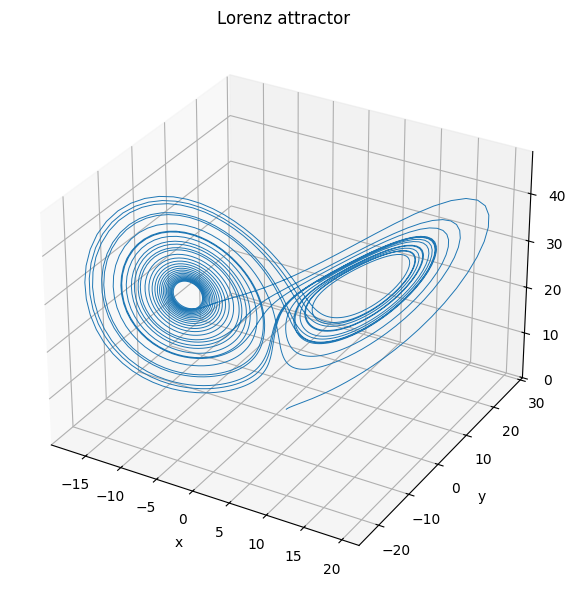

In [6]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(X[:, 0], X[:, 1], X[:, 2], linewidth=0.7)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz attractor")

plt.tight_layout()
plt.show()

## Build polynomial candidate library

We use a degree-2 polynomial library:

Theta(X) = [1, x, y, z, x^2, xy, xz, y^2, yz, z^2]

The true Lorenz system only uses:

- x and y in the x_dot equation
- x, y, and xz in the y_dot equation
- xy and z in the z_dot equation

So the true equations are sparse in this larger library.

In [7]:
Theta, feature_names = build_polynomial_library(
    X,
    degree=2,
    include_constant=True,
)

print("Theta shape:", Theta.shape)
print("Feature names:")
print(feature_names)

Theta shape: (3000, 10)
Feature names:
['1', 'x1', 'x2', 'x3', 'x1^2', 'x1x2', 'x1x3', 'x2^2', 'x2x3', 'x3^2']


## Fit SINDy with STLSQ

We solve:

dXdt = Theta(X) * Xi

where Xi is the sparse coefficient matrix.

Rows correspond to library terms.

Columns correspond to:

x_dot, y_dot, z_dot

In [8]:
Xi = stlsq(
    Theta,
    dXdt,
    threshold=0.05,
    max_iter=20,
)

coef_table = {}

for name, row in zip(feature_names, Xi):
    coef_table[name] = row

print("Xi shape:", Xi.shape)
print("Xi:")
print(Xi)

Xi shape: (10, 3)
Xi:
[[  0.           0.           0.        ]
 [-10.          28.           0.        ]
 [ 10.          -1.           0.        ]
 [  0.           0.          -2.66666667]
 [  0.           0.           0.        ]
 [  0.           0.           1.        ]
 [  0.          -1.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]]


In [9]:
target_names = ["x_dot", "y_dot", "z_dot"]

def print_sindy_equations(feature_names, Xi, target_names, tolerance=1e-10):
    for target_idx, target_name in enumerate(target_names):
        terms = []

        for feature_name, coefficient in zip(feature_names, Xi[:, target_idx]):
            if abs(coefficient) <= tolerance:
                continue

            if feature_name == "1":
                terms.append(f"{coefficient:.6g}")
            else:
                terms.append(f"{coefficient:.6g}*{feature_name}")

        equation = " + ".join(terms) if terms else "0"
        print(f"{target_name} = {equation}")

print_sindy_equations(feature_names, Xi, target_names)

x_dot = -10*x1 + 10*x2
y_dot = 28*x1 + -1*x2 + -1*x1x3
z_dot = -2.66667*x3 + 1*x1x2


## Expected equations

The true Lorenz equations are:

x_dot = -10*x + 10*y

y_dot = 28*x - 1*y - 1*xz

z_dot = 1*xy - 2.6667*z

So we want SINDy to discover these terms from the larger library:

[1, x, y, z, x^2, xy, xz, y^2, yz, z^2]

In [11]:
expected_Xi = np.zeros_like(Xi)

name_to_idx = {name: idx for idx, name in enumerate(feature_names)}

# x_dot = -10*x + 10*y
expected_Xi[name_to_idx["x1"], 0] = -10.0
expected_Xi[name_to_idx["x2"], 0] = 10.0

# y_dot = 28*x - y - x*z
expected_Xi[name_to_idx["x1"], 1] = 28.0
expected_Xi[name_to_idx["x2"], 1] = -1.0
expected_Xi[name_to_idx["x1x3"], 1] = -1.0

# z_dot = x*y - beta*z
expected_Xi[name_to_idx["x1x2"], 2] = 1.0
expected_Xi[name_to_idx["x3"], 2] = -(8.0 / 3.0)

print("Expected Xi:")
print(expected_Xi)

print()
print("Recovered Xi:")
print(Xi)

print()
print("Coefficient error:")
print(Xi - expected_Xi)

Expected Xi:
[[  0.           0.           0.        ]
 [-10.          28.           0.        ]
 [ 10.          -1.           0.        ]
 [  0.           0.          -2.66666667]
 [  0.           0.           0.        ]
 [  0.           0.           1.        ]
 [  0.          -1.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]]

Recovered Xi:
[[  0.           0.           0.        ]
 [-10.          28.           0.        ]
 [ 10.          -1.           0.        ]
 [  0.           0.          -2.66666667]
 [  0.           0.           0.        ]
 [  0.           0.           1.        ]
 [  0.          -1.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]
 [  0.           0.           0.        ]]

Coefficient error:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-5.32907052e-15  1.77635684e-14  0.00000000e+00]
 [-1.776

## Derivative prediction error

We now check how well the discovered equations reproduce the instantaneous derivatives.

This is different from long-run simulation accuracy. Chaotic systems are sensitive to initial conditions, so long-run trajectories can diverge even when the recovered equations are very accurate.

In [13]:
dXdt_hat = Theta @ Xi

mse_derivative = np.mean((dXdt - dXdt_hat) ** 2, axis=0)

print("Derivative MSE by component:")
print("x_dot:", mse_derivative[0])
print("y_dot:", mse_derivative[1])
print("z_dot:", mse_derivative[2])

Derivative MSE by component:
x_dot: 3.383516704417257e-27
y_dot: 5.7063241859399865e-27
z_dot: 4.7254648998613474e-27


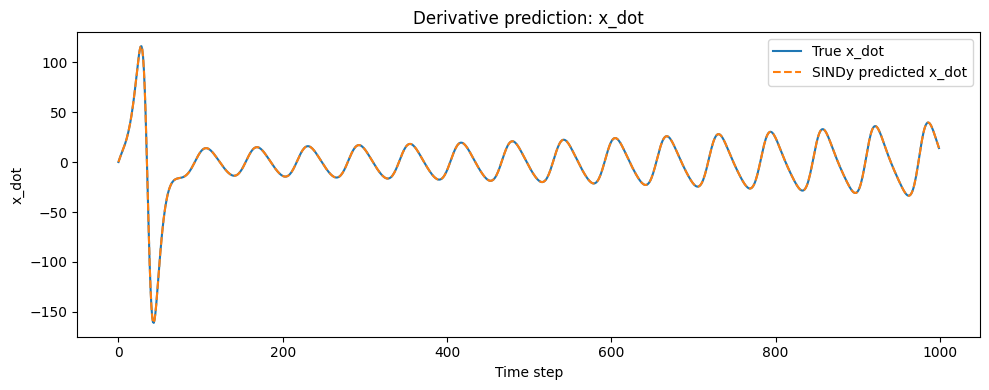

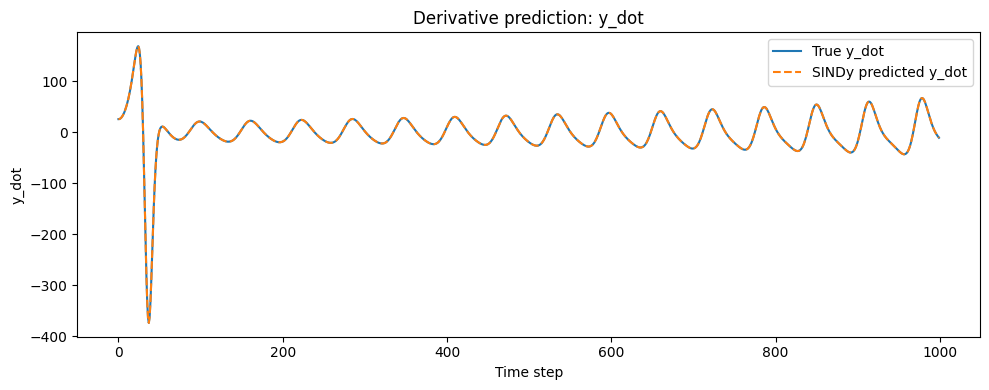

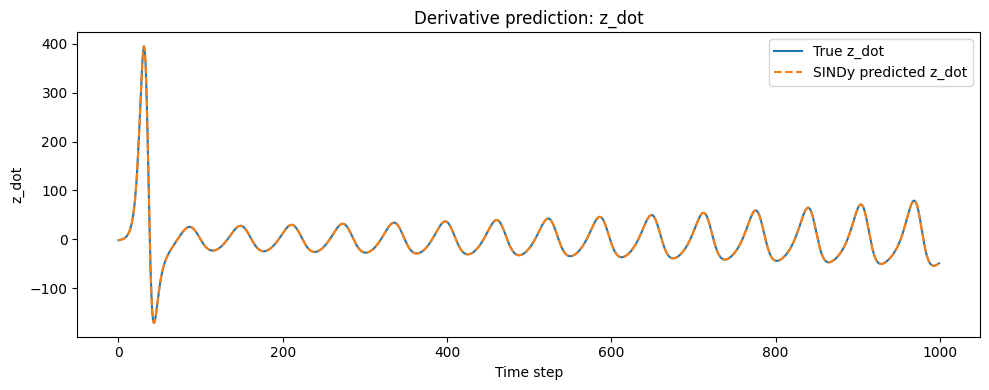

In [14]:
n_plot = 1000

for i, name in enumerate(target_names):
    plt.figure(figsize=(10, 4))
    plt.plot(dXdt[:n_plot, i], label=f"True {name}")
    plt.plot(dXdt_hat[:n_plot, i], "--", label=f"SINDy predicted {name}")
    plt.xlabel("Time step")
    plt.ylabel(name)
    plt.title(f"Derivative prediction: {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Threshold sweep

The STLSQ threshold controls sparsity.

If the threshold is too low, extra small coefficients may remain.

If the threshold is too high, true terms may be removed.

We sweep over several threshold values and track:

- number of active coefficients
- derivative MSE

In [17]:
import pandas as pd
thresholds = [1e-6, 1e-4, 1e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1.0]

sweep_rows = []

for threshold in thresholds:
    Xi_sweep = stlsq(
        Theta,
        dXdt,
        threshold=threshold,
        max_iter=20,
    )

    dXdt_hat_sweep = Theta @ Xi_sweep

    mse_sweep = np.mean((dXdt - dXdt_hat_sweep) ** 2)
    active_terms = np.sum(np.abs(Xi_sweep) > 0)

    sweep_rows.append({
        "threshold": threshold,
        "active_terms": active_terms,
        "derivative_mse": mse_sweep,
    })

threshold_sweep_lorenz = pd.DataFrame(sweep_rows)

print(threshold_sweep_lorenz)

   threshold  active_terms  derivative_mse
0   0.000001             7    4.605102e-27
1   0.000100             7    4.605102e-27
2   0.001000             7    4.605102e-27
3   0.010000             7    4.605102e-27
4   0.050000             7    4.605102e-27
5   0.100000             7    4.605102e-27
6   0.500000             7    4.605102e-27
7   1.000000             4    2.185094e+03


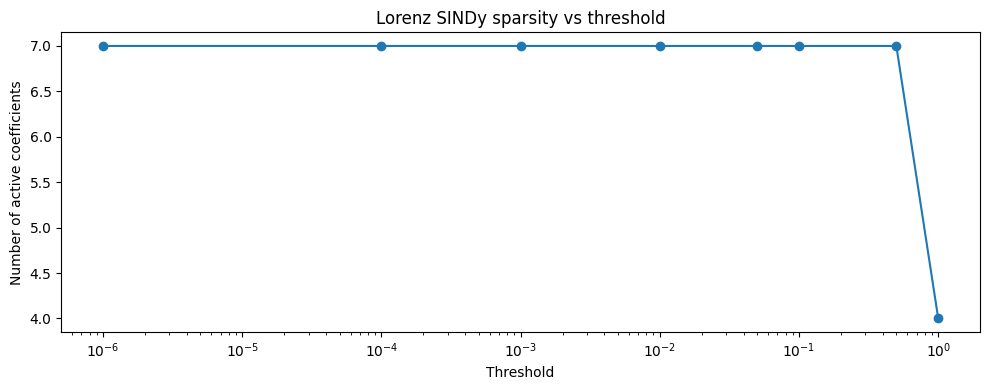

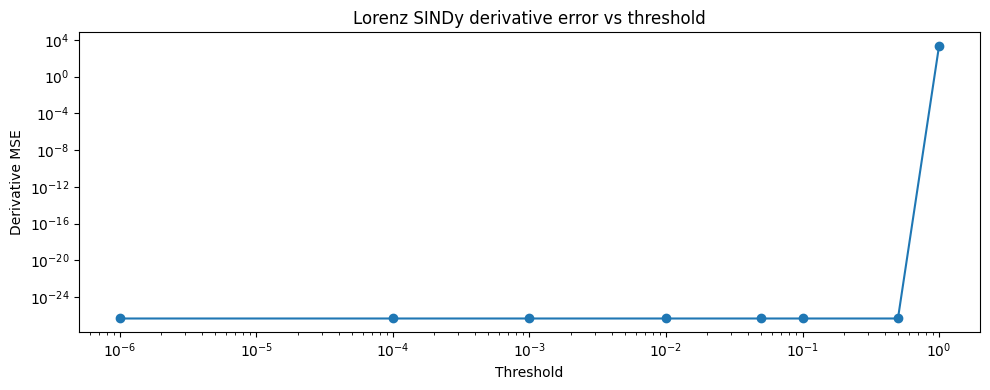

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(
    threshold_sweep_lorenz["threshold"],
    threshold_sweep_lorenz["active_terms"],
    marker="o",
)
plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Number of active coefficients")
plt.title("Lorenz SINDy sparsity vs threshold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(
    threshold_sweep_lorenz["threshold"],
    threshold_sweep_lorenz["derivative_mse"],
    marker="o",
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Threshold")
plt.ylabel("Derivative MSE")
plt.title("Lorenz SINDy derivative error vs threshold")
plt.tight_layout()
plt.show()

## Conclusion

The Lorenz experiment provides a clean positive control for the SINDy implementation.

Using a degree-2 polynomial library,

[1, x, y, z, x^2, xy, xz, y^2, yz, z^2],

SINDy recovers the true sparse Lorenz equations almost exactly:

x_dot = -10*x + 10*y

y_dot = 28*x - y - x*z

z_dot = x*y - 2.6667*z

The coefficient errors are only at numerical precision level, and the derivative MSE is essentially zero.

The threshold sweep shows that the correct 7 active terms remain selected for thresholds up to 0.5. At threshold 1.0, important terms with coefficient magnitude 1 are removed, causing the error to increase sharply.

This experiment demonstrates the core SINDy idea under ideal conditions: when the true dynamics are sparse, stable, and contained in the candidate library, SINDy can recover the governing equations from data.

This contrasts with the real yield-curve experiments. For daily Treasury yield data, the observed state variables do not form a closed physical system, and the dynamics are affected by noise, regime changes, and exogenous information. Therefore, SINDy identifies candidate structures but does not deliver robust forecasting performance.